In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

1. Data Preparation:

Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [13]:
# Load the Excel file and check available sheet names
xls = pd.ExcelFile('heart_disease.xlsx')
xls.sheet_names


['Description', 'Heart_disease']

In [17]:
# Load the Heart_disease sheet
df_heart = pd.read_excel('heart_disease.xlsx', sheet_name="Heart_disease")

In [37]:
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


2. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.

Check for missing values, outliers, and inconsistencies in the data.

In [24]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [43]:
df_heart.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

Missing Values: The "oldpeak" column has 62 missing values

In [35]:
df_heart.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


"trestbps" (resting blood pressure) and "chol" (cholesterol) have a few extreme values.

Visualize the distribution of features, including histograms, box plots, and correlation matrices.

<Figure size 1200x600 with 0 Axes>

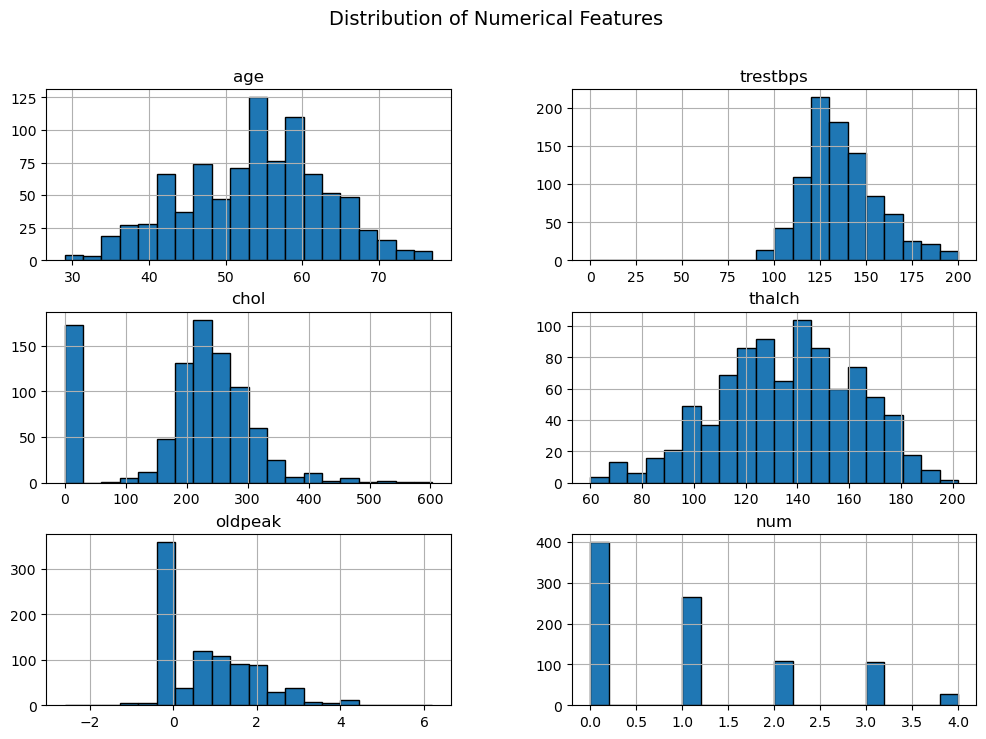

In [51]:
# Visualizing distribution of numerical features
plt.figure(figsize=(12, 6))
df_heart.hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

3. Feature Engineering:

If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [47]:
# Fill missing values in 'oldpeak' with the median
df_heart["oldpeak"].fillna(df_heart["oldpeak"].median(), inplace=True)


In [49]:
df_heart.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()


In [56]:
# Convert categorical variables into numerical using Label Encoding
categorical_cols = ["sex", "cp", "restecg", "exang", "slope", "thal"]
label_encoders = {}

In [60]:
# Check unique values in problematic columns
unique_values = {col: df_heart[col].unique() for col in ["exang", "slope", "thal"]}
unique_values


{'exang': array([False, True, 'FALSE', 'TURE'], dtype=object),
 'slope': array(['downsloping', 'flat', 'upsloping'], dtype=object),
 'thal': array(['fixed defect', 'normal', 'reversable defect'], dtype=object)}

In [64]:
# Standardize "exang" column (convert to boolean values)
df_heart["exang"] = df_heart["exang"].astype(str).str.upper().replace({"FALSE": False, "TURE": True, "TRUE": True}).astype(bool)


In [66]:
# Convert categorical columns to string format before encoding
df_heart[categorical_cols] = df_heart[categorical_cols].astype(str)

In [68]:
for col in categorical_cols:
    le = LabelEncoder()
    df_heart[col] = le.fit_transform(df_heart[col])
    label_encoders[col] = le  # Store encoders for future reference


In [70]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    int32  
 2   cp        908 non-null    int32  
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    int32  
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    int32  
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    int32  
 11  thal      908 non-null    int32  
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int32(6), int64(5)
memory usage: 64.9 KB


In [72]:
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,0,2.3,0,0,0
1,41,1,1,135,203,False,1,132,0,0.0,1,0,0
2,57,1,0,140,192,False,1,148,0,0.4,1,0,0
3,52,1,3,118,186,False,0,190,0,0.0,1,0,0
4,57,1,0,110,201,False,1,126,1,1.5,1,0,0


4. Decision Tree Classification:

Split the dataset into training and testing sets (e.g., using an 80-20 split).

In [82]:
# Define features and target variable
X = df_heart.drop(columns=["num"])  # Features
y = df_heart["num"]  # Target

In [84]:
# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

Implement a Decision Tree Classification model using a library like scikit-learn.

In [92]:
# Initialize and train Decision Tree model
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [90]:
y_pred = clf.predict(X_test)
y_pred

array([0, 1, 0, 1, 0, 2, 2, 1, 1, 2, 1, 3, 3, 1, 0, 3, 0, 0, 0, 2, 2, 1,
       0, 1, 2, 0, 1, 3, 0, 3, 1, 0, 2, 0, 0, 0, 2, 0, 1, 0, 2, 1, 2, 1,
       3, 2, 0, 3, 1, 2, 2, 2, 3, 3, 1, 1, 2, 1, 0, 3, 0, 1, 0, 2, 1, 2,
       1, 0, 2, 0, 3, 2, 0, 2, 3, 2, 2, 3, 3, 1, 1, 4, 1, 1, 4, 2, 1, 1,
       0, 0, 3, 1, 0, 1, 1, 3, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 3, 0, 0, 2,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 4, 0, 0, 0, 0, 2, 0, 1, 1, 0, 1, 1,
       0, 3, 2, 3, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 0, 3, 0,
       0, 1, 3, 3, 1, 0, 1, 4, 1, 3, 2, 0, 1, 0, 0, 1, 0, 0, 0, 1, 3, 0,
       2, 0, 3, 1, 1, 0], dtype=int64)

Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [94]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [96]:
accuracy

0.47802197802197804

5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

6. Model Evaluation and Analysis:

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

Visualize the decision tree structure to understand the rules learned by the model and identify important features


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.65      0.69        80
           1       0.44      0.43      0.44        53
           2       0.23      0.32      0.27        22
           3       0.22      0.24      0.23        21
           4       0.17      0.17      0.17         6

    accuracy                           0.48       182
   macro avg       0.36      0.36      0.36       182
weighted avg       0.51      0.48      0.49       182



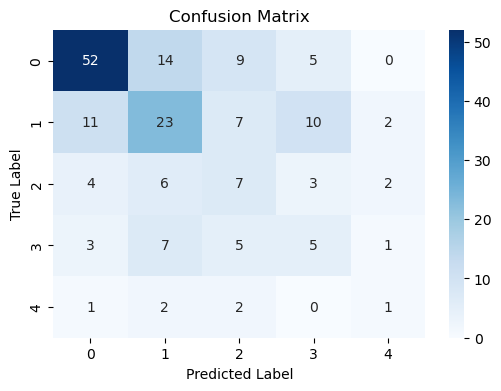

In [116]:
# Predictions
y_pred = clf.predict(X_test)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


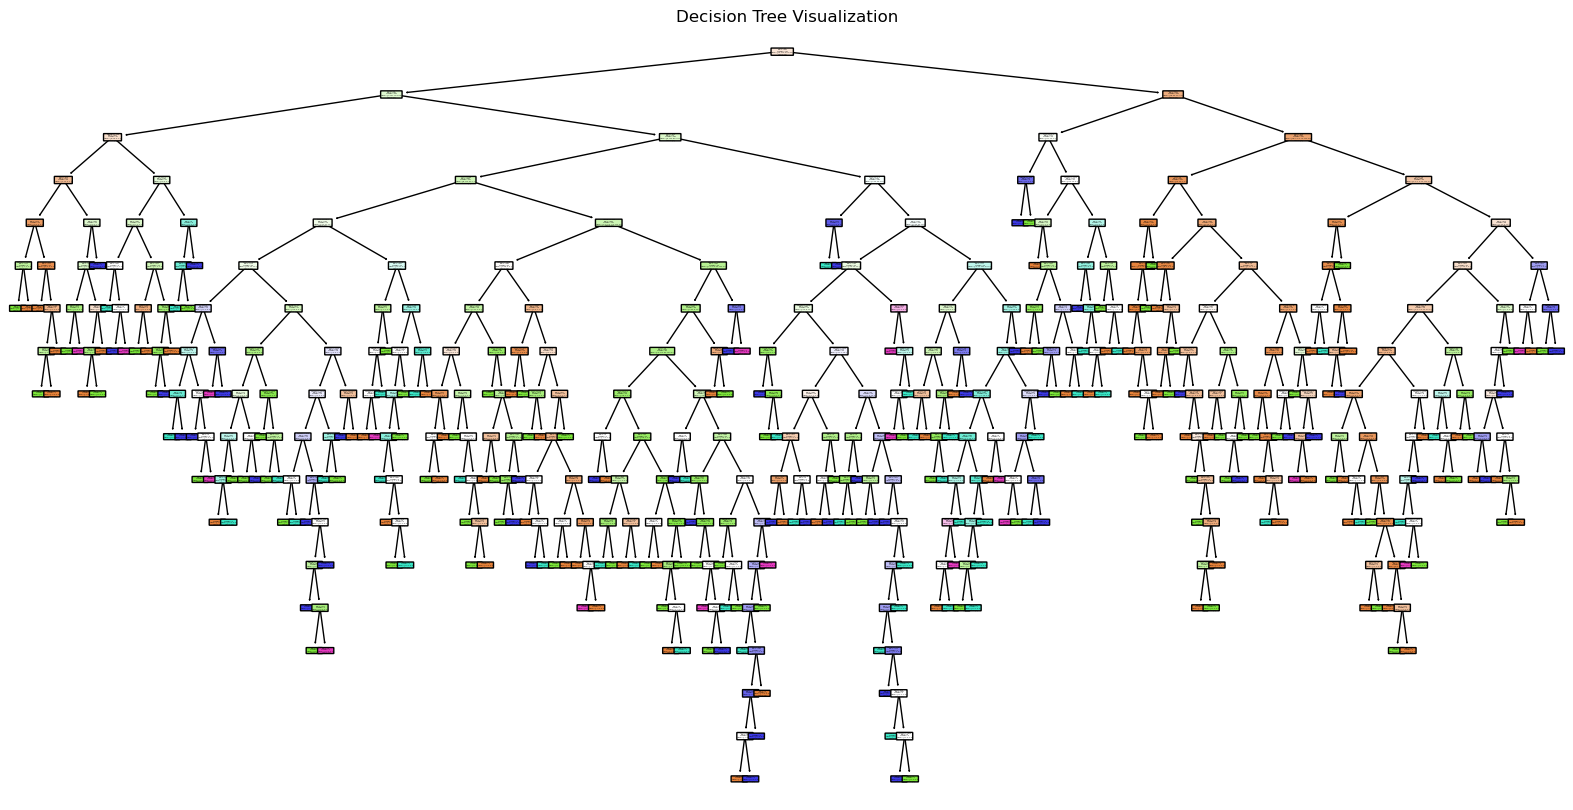

In [118]:
# Plot the decision tree structure
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=True, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()


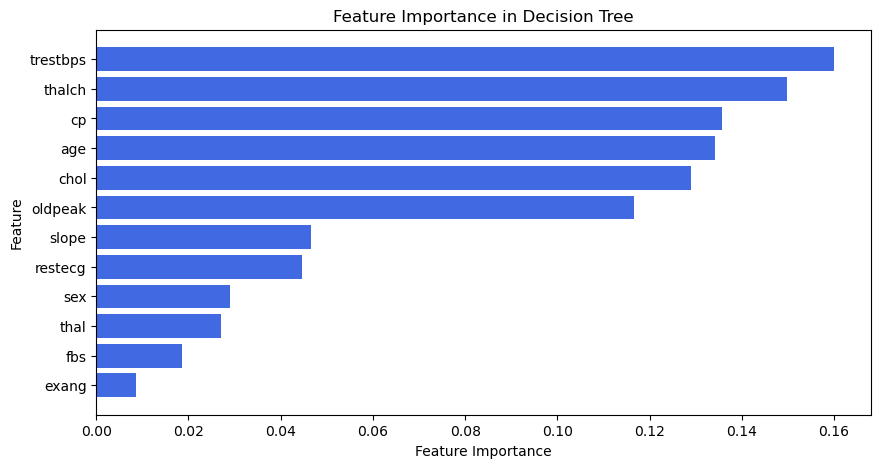

In [120]:
# Get feature importance scores
feature_importance = clf.feature_importances_

# Sort and plot
sorted_idx = np.argsort(feature_importance)[::-1]
plt.figure(figsize=(10,5))
plt.barh(X.columns[sorted_idx], feature_importance[sorted_idx], color='royalblue')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Decision Tree")
plt.gca().invert_yaxis()
plt.show()


In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Create GridSearchCV
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy')

# Fit on training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report for Tuned Model:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


1. Common Hyperparameters in Decision Trees & Their Effects
Decision Tree models have several key hyperparameters that impact their performance:


max_depth-->Maximum depth of the tree--> Limits overfitting. A shallow tree may          underfit, while a deep tree may overfit.

min_samples_split-->Minimum samples required to split a node-->Higher values prevent overfitting but may underfit the data.

min_samples_leaf-->Minimum samples required in a leaf node-->Higher values create a smoother decision boundary.

criterion-->Splitting criteria: gini or entropy-->gini is faster; entropy provides more information gain but is computationally heavier.

max_features-->Number of features to consider for the best split-->Controls randomness; fewer features increase bias, more features increase variance.

ccp_alpha-->Cost-complexity pruning parameter-->Prunes unnecessary branches to prevent overfitting.

2. What is the difference between the Label encoding and One-hot encoding?

Label Encoding-->Assigns a unique numerical value to each category (e.g., {"Red": 0, "Blue": 1, "Green": 2}).-->When categorical values have an ordinal relationship (e.g., "Low", "Medium", "High").

One-Hot Encoding-->Creates separate binary columns for each category (e.g., Red → [1,0,0], Blue → [0,1,0], Green → [0,0,1]).-->When categorical values are nominal (no order) (e.g., "Dog", "Cat", "Bird")